In [1]:
import rush_hour_rl as rl
import rush_hour_lib as lib
import random
import torch


In [2]:
puzzles = lib.sample_unique()
puzzle = puzzles[30]

## Apprentice/teacher (ExIt) model, plain behavior cloning

Trains via `train_policy_bc` (supervised imitation of AND-OR: one batch of solve attempts, one training pass) rather than DQN. `PolicyAgent` is policy-only (no value head) and its greedy rollout uses `policy_avoiding_cycles`: it ranks legal actions by logit and falls back to the next-best one whenever the top choice would revisit an already-seen state, so a single bad decision can't strand the rollout in a 2-cycle until `max_steps` runs out. `train_policy` also applies an exponential moving average (`ema_decay`) over the trained weights across epochs, smoothing the epoch-to-epoch instability visible in `steps_history` below.</cell id="65441130">


In [3]:
apprentice_cars = [name for name, _ in puzzle]
apprentice_initial = [(name, list(positions)) for name, positions in puzzle]


In [4]:
# Seeded for reproducibility - torch.manual_seed matters as much as
# random.seed here: random.seed alone only controls AND-OR's own search,
# not PyTorch's weight init / batch shuffling, a separate source of
# run-to-run variance in whether the policy head solves independently.
random.seed(3)
torch.manual_seed(0)

agent, examples, steps_history, stats = rl.train_policy_bc(
    apprentice_cars, apprentice_initial, (6, 6),
    n_traces=3000, epochs=1000, max_steps=200,
    and_or_eval_trials=30,
)
n_examples, policy_loss, policy_solved, policy_steps, and_or_solve_rate, and_or_avg_moves = stats
print(f"examples={n_examples}  policy_loss={policy_loss:.3f}")
print(f"policy_solved={policy_solved}  policy_steps={policy_steps}")
print(f"and_or_solve_rate={and_or_solve_rate}  and_or_avg_moves={and_or_avg_moves}")


training epochs: 100%|██████████| 1000/1000 [00:33<00:00, 29.63it/s]


examples=12338  policy_loss=0.959
policy_solved=True  policy_steps=54
and_or_solve_rate=0.0  and_or_avg_moves=nan


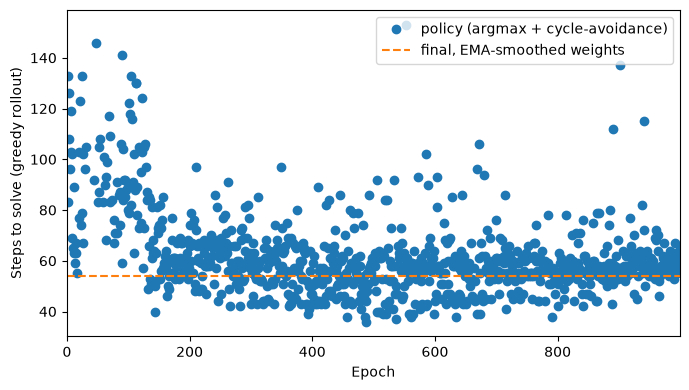

In [5]:
import matplotlib.pyplot as plt

epochs = [e for e, _ in steps_history]
policy_steps_curve = [s for _, s in steps_history]

plt.figure(figsize=(7, 4))
# linestyle="None": these are isolated solved/unsolved checkpoints, not a
# continuous quantity - a connecting line would draw a straight (and
# misleading) segment across epochs that didn't solve (nan) in between.
plt.plot(epochs, policy_steps_curve, marker="o", linestyle="None", label="policy (argmax + cycle-avoidance)")
if policy_steps is not None:
    plt.axhline(policy_steps, color="tab:orange", linestyle="--", label="final, EMA-smoothed weights")
plt.xlabel("Epoch"); plt.ylabel("Steps to solve (greedy rollout)")
plt.xlim(-0.5, len(steps_history) - 0.5)
plt.legend()
plt.tight_layout()
plt.savefig("visualization/apprentice_bc.png")
plt.show()
